# 01 -  EAD

In [66]:
import os
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import logging
logging.getLogger().setLevel(logging.CRITICAL)

In [67]:
# Packages version
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')
print(f'logging: {logging.__version__}')

pandas: 2.3.1
numpy: 2.2.6
matplotlib: 3.10.3
seaborn: 0.13.2
logging: 0.5.1.2


# 📈 **Survival Analisis**

This project applies the **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) methodology to build and evaluate a credit risk scoring model. The process is structured in the following phases:

- **🔎 Business Understanding**  
  Define objectives and understand the business problem of assessing credit risk.

- **📊 Data Understanding**  
  Collect, describe, and explore the dataset to identify data quality issues and gain initial insights.

- **🛠️ Data Preparation**  
  Clean and transform data, engineer features, and create the final modeling dataset.

- **🤖 Modeling**  
  Train and optimize predictive models to assess credit risk scores.

- **✅ Evaluation**  
  Assess model performance against business goals using appropriate metrics.

- **🚀 Deployment**  
  Prepare the model for production use, enabling integration into decision-making workflows. **(Will not be contemplated in this project)**


In [68]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cindybtari/survival-analysis-dataset")
print("Path to dataset files:", path)

csv_path = os.path.join(path, "dialysis survival dataset.csv")  
df = pd.read_csv(csv_path)

df.head()

Path to dataset files: /Users/michelgonzagadossantos/.cache/kagglehub/datasets/cindybtari/survival-analysis-dataset/versions/1


,event,time,age,begin,center,disease_diabetes,disease_hypert,disease_other,disease_renal
0,0,1,59,35,120,0,1,0,0
1,0,3,49,38,120,0,1,0,0
2,0,18,49,22,120,0,0,1,0
3,0,2,52,21,120,0,1,0,0
4,1,1,89,41,120,0,1,0,0


In [69]:
df.columns

Index(['event', 'time', 'age', 'begin', 'center', 'disease_diabetes',
       'disease_hypert', 'disease_other', 'disease_renal'],
      dtype='object')

In [70]:
# Dataset without null values
# 6805 rows
# 9 columns
# Only numerical values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6805 entries, 0 to 6804
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   event             6805 non-null   int64
 1   time              6805 non-null   int64
 2   age               6805 non-null   int64
 3   begin             6805 non-null   int64
 4   center            6805 non-null   int64
 5   disease_diabetes  6805 non-null   int64
 6   disease_hypert    6805 non-null   int64
 7   disease_other     6805 non-null   int64
 8   disease_renal     6805 non-null   int64
dtypes: int64(9)
memory usage: 478.6 KB


In [71]:
df[['time','begin','center']].describe()

,time,begin,center
count,6805.000000,6805.000000,6805.000000
mean,14.157972,22.777517,2553.106392
std,12.022840,12.442597,1907.061885
min,1.000000,1.000000,120.000000
25%,3.000000,12.000000,1039.000000
50%,11.000000,23.000000,2026.000000
75%,22.000000,33.000000,4163.000000
max,44.000000,44.000000,5768.000000


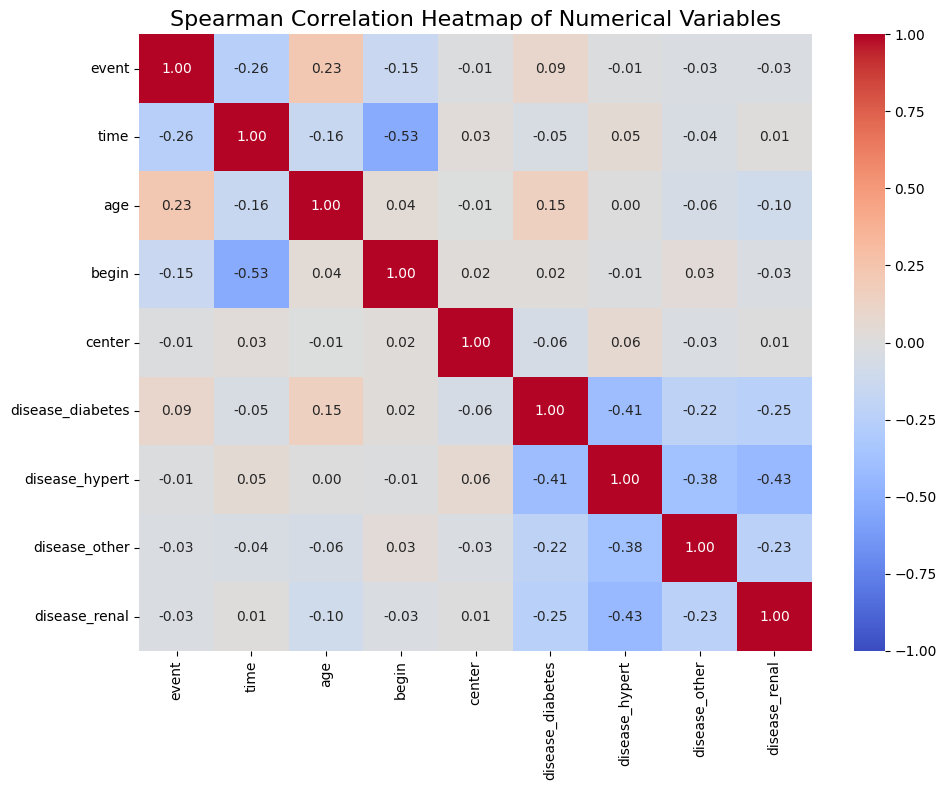

In [72]:
# Compute the correlation matrix
corr_matrix = df.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [73]:
# Correlation between the target variable (event) and the numerical features of the Data set

print(140*'-')
print('Correlation between the target variable (event) and the numerical features of the Data set')
print(140*'-')
print('The Four Variables Most Strongly Correlated with event (absolute value):')

for col, val in abs(df.drop(columns='time').corr(method='spearman')['event']) \
                    .sort_values(ascending=False)[1:5].items():
    print(col, val)

print(140*'-')
print('Obs. None of the atributes present a strong correlation with event!')

--------------------------------------------------------------------------------------------------------------------------------------------
Correlation between the target variable (event) and the numerical features of the Data set
--------------------------------------------------------------------------------------------------------------------------------------------
The Four Variables Most Strongly Correlated with event (absolute value):
age 0.22629432006016956
begin 0.14620605824719773
disease_diabetes 0.08922005460853223
disease_other 0.02995088674018186
--------------------------------------------------------------------------------------------------------------------------------------------
Obs. None of the atributes present a strong correlation with event!


In [74]:
# Correlation between the target variable (time) and the numerical features of the Data set

print(140*'-')
print('Correlation between the target variable (time) and the numerical features of the Data set')
print(140*'-')
print('The Four Variables Most Strongly Correlated with event (absolute value):')

for col, val in abs(df.drop(columns='event').corr(method='spearman')['time']) \
                    .sort_values(ascending=False)[1:5].items():
    print(col, val)

print(140*'-')
print('Obs. None of the atributes present a strong correlation with time!')

--------------------------------------------------------------------------------------------------------------------------------------------
Correlation between the target variable (time) and the numerical features of the Data set
--------------------------------------------------------------------------------------------------------------------------------------------
The Four Variables Most Strongly Correlated with event (absolute value):
begin 0.5281196652311188
age 0.1559390254542185
disease_hypert 0.05036291593171903
disease_diabetes 0.046402640202128594
--------------------------------------------------------------------------------------------------------------------------------------------
Obs. None of the atributes present a strong correlation with time!


## Bar plot of the event variable


/var/folders/jd/dg4_wpm92qlc7b6h0sj03kr40000gn/T/ipykernel_59788/2610548991.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




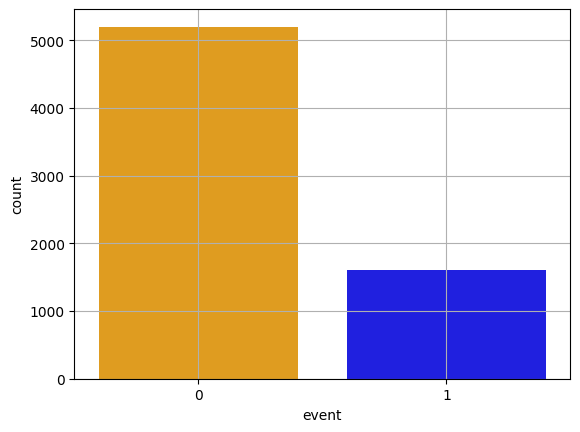

In [75]:
sns.countplot(df, x="event", palette=['orange', 'blue'])
plt.grid()

In [76]:
counts, bin_edges = np.histogram(df.age, bins=5)

df["age_bin"] = pd.cut(df.age, bins=bin_edges, include_lowest=True)

dict_age_bins = {val: idx for idx, val in enumerate(df["age_bin"].unique().sort_values())}
df["age_group"] = df["age_bin"].apply(lambda x: 'Group ' + str(dict_age_bins[x]))

In [89]:
df.groupby('age_group').size().reset_index(name='total')

/var/folders/jd/dg4_wpm92qlc7b6h0sj03kr40000gn/T/ipykernel_59788/2905984146.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,age_group,total
0,Group 0,151
1,Group 1,1172
2,Group 2,2851
3,Group 3,2283
4,Group 4,348


In [78]:
age_counts = df.groupby('age_group').size().reset_index(name='total')
age_counts.columns = ['age_group', 'total']

# Gráfico
fig = px.pie(age_counts, names='age_group', values='total',
             title="Distribution of the population by age group",
             hole=0)  # use hole=0.4 para doughnut

fig.show()


/var/folders/jd/dg4_wpm92qlc7b6h0sj03kr40000gn/T/ipykernel_59788/1813051676.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



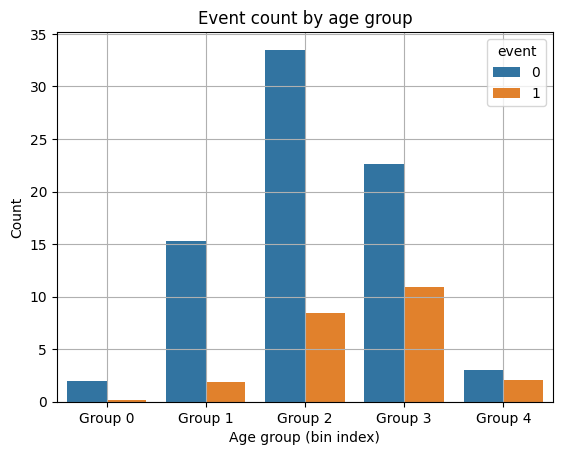

In [79]:
sns.countplot(x="age_group", hue='event', data=df, stat="percent")
plt.xlabel("Age group (bin index)")
plt.ylabel("Count")
plt.title("Event count by age group")
plt.grid()
plt.show()

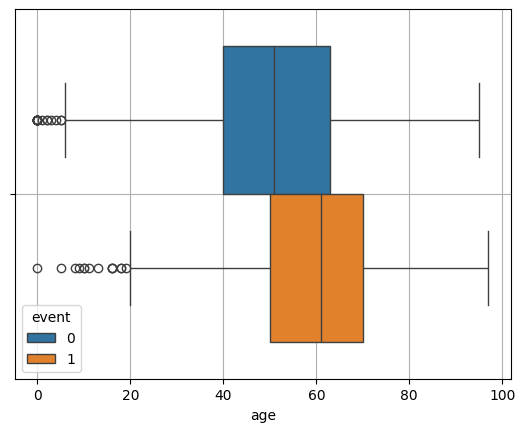

In [80]:
sns.boxplot(df,x='age',hue='event')
plt.grid()

In [81]:
df.groupby('event')['age'].agg(["mean", "std", "count"]).add_prefix('Age_')


,Age_mean,Age_std,Age_count
event,,,
0,50.698385,16.045993,5202
1,59.187149,14.915615,1603


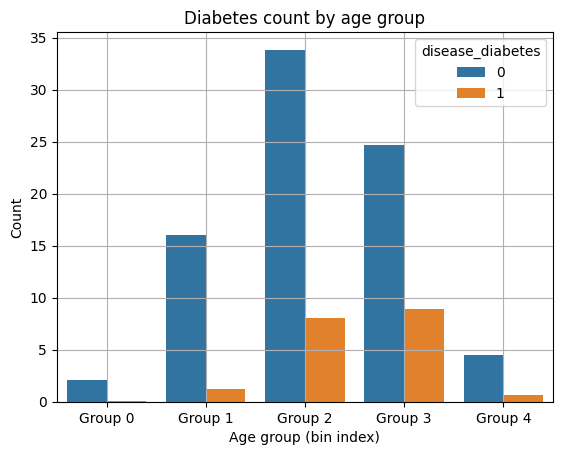

In [82]:
sns.countplot(x="age_group", hue='disease_diabetes', data=df, stat="percent")
plt.xlabel("Age group (bin index)")
plt.ylabel("Count")
plt.title("Diabetes count by age group")
plt.grid()
plt.show()

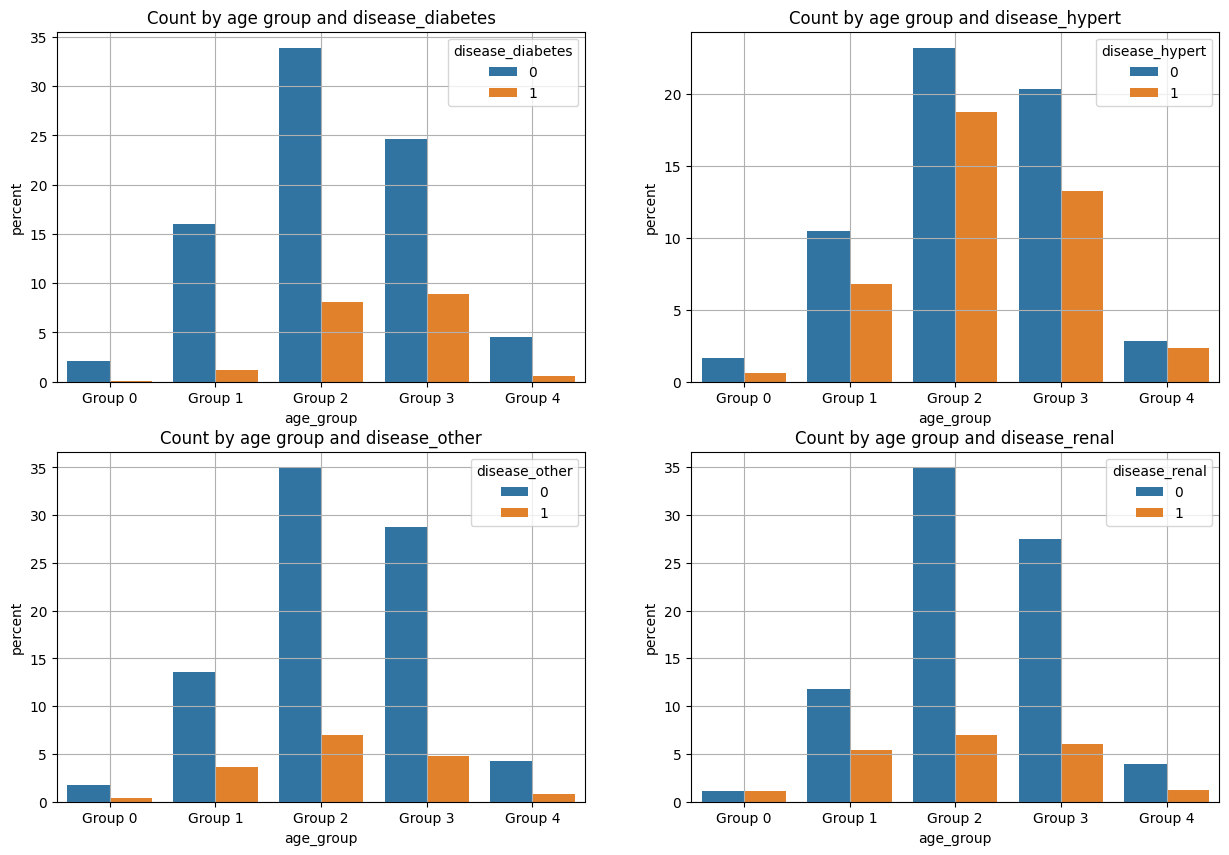

<Figure size 640x480 with 0 Axes>

In [83]:
disease_list = [col for col in df.columns if 'disease' in col]


fig, axs = plt.subplots(2, 2, figsize=(15, 10)) 
for col,ax in zip(disease_list,axs.flatten()):
    sns.countplot(x="age_group", hue=col, data=df, ax=ax, stat="percent")
    ax.set_title(f'Count by age group and {col}')
    ax.grid()
plt.show()
plt.tight_layout()

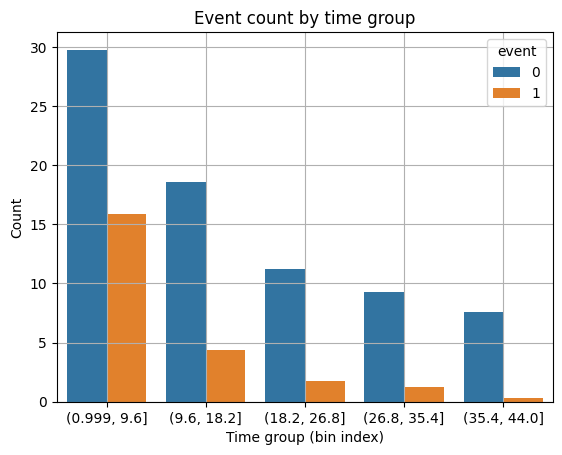

In [84]:
counts, bin_edges = np.histogram(df.time, bins=5)

df["time_bin"] = pd.cut(df.time, bins=bin_edges, include_lowest=True)

#dict_age_bins = {val: idx for idx, val in enumerate(df["age_bin"].unique().sort_values())}
#df["age_group"] = df["age_bin"].map(dict_age_bins)

sns.countplot(x="time_bin", hue='event', data=df, stat="percent")
plt.xlabel("Time group (bin index)")
plt.ylabel("Count")
plt.title("Event count by time group")
plt.grid()
plt.show()

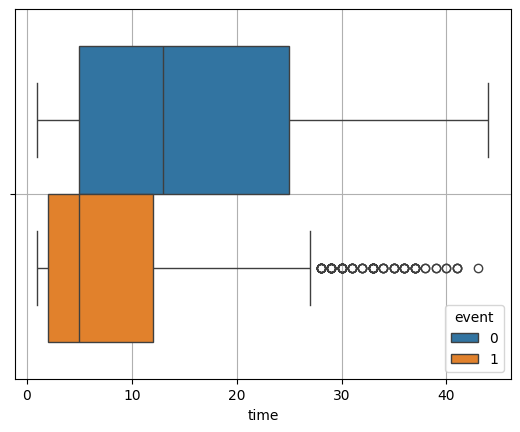

In [85]:
sns.boxplot(df,x='time',hue='event')
plt.grid()

<Axes: xlabel='time', ylabel='age'>

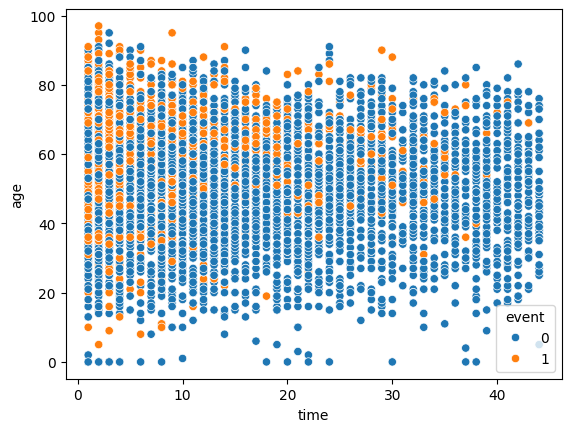

In [86]:
sns.scatterplot(df, x='time', y='age', hue='event')

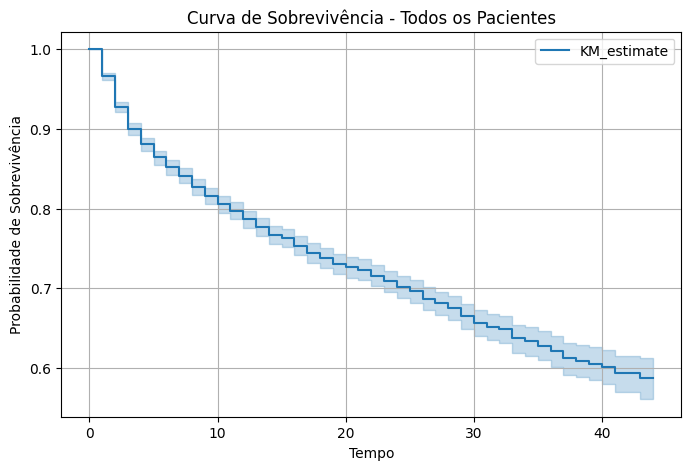

In [87]:
from lifelines import KaplanMeierFitter, CoxPHFitter
kmf = KaplanMeierFitter()
kmf.fit(df["time"], event_observed=df["event"])

# Plot
plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title("Curva de Sobrevivência - Todos os Pacientes")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid()
plt.show()
